In [1]:
import sys
sys.path.append('..')
sys.path.append('./data_files')

from math import *
import numpy as np
import numpy.fft as fft
import matplotlib.pyplot as plt

from scipy import signal
from scipy.optimize import minimize_scalar
from scipy.io.wavfile import read
from scipy.signal import resample

from numpy.random import seed
from numpy.random import shuffle

import time

import Pylos_toolkit as PyT

# Only possible when ran from linux:
import pycbc.filter
import pycbc.psd
from pycbc import types
from pycbc.types.array import complex_same_precision_as
from pycbc import fft
import sys
sys.path.append('../..')
import report_plotstyle

# hydrophone and JPP matched filter imports
from fibre_hydrophone import *
from matched_filter import *


/home/hbaetsen/miniconda3/envs/root39/lib/python3.9/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


# Python version of JPP matched filter evaluation
This notebook is intended to evaluate the performance of the hydrophone-response integrated matched filter as implemented in JPP. The goal of this notebook is direct comparison between the PyCBC package and the new implementation. Note that this is not the full JPP implementation where the signal and noise contributions are split.

The main implementation of the matched filter can be found in `matched_filter.py` along with an implementation of the hydrophone in `fibre_hydrophone.py`

## Part 1: Imports

In [2]:
sampling_rate = 144e3
dt            = 1 / sampling_rate

t, y, sampling_rate, _ = PyT.load_Pylos_data('../201650198.180131085932.wav', trace_length_s=10)
y -= np.mean(y)

Sampling rate:          144000 Hz
Length of time series:  120 minutes
Length of output time series:  10 seconds


In [3]:
# read template from file
template                        = np.loadtxt("./data_files/template_1e11_6_1000")
t_template, p_template          = template[:, 0], template[:, 1]
L_template                      = len(p_template)

# read PSD from file (same as PSD from first 10 seconds of y)
PSD0                            = np.fromfile("./data_files/Pylos_PSD_4096.bin", dtype=np.float64)

# read data pulse from file
testpulse_bad                   = np.loadtxt("./data_files/data_1e11_20_600") 
testpulse_good                  = np.loadtxt("./data_files/template_1e11_6_1000")

t_testpulse, p_testpulse_good   = testpulse_good[:, 0], testpulse_good[:, 1]
p_testpulse_bad                 = testpulse_bad[:, 1]
L_testpulse                     = len(p_testpulse_good)

## Part 2: Set parameters

In [ ]:
Nt                  = 4096
length              = Nt
np.random.seed(0)

# -> windowing              : whether to window the matched filter in the frequency domain
# -> hydrophone             : whether to include the hydrophone response in the analysis
# -> give_noise             : whether to add noise to the test trace
# -> give_signal            : whether to add a signal to the test trace
#    -> alternative_signal  : whether to use a signal that is not identical to the template
# -> filter_template        : whether to filter the template with the hydrophone response

windowing           = True
hydrophone          = True
give_noise          = True
give_signal         = True
alternative_signal  = False
filter_template     = True

# Parameters
SS                  = 0     # [-]     seastate
f_L                 = 1000  # [Hz]    lower frequency limit - only if windowing    
f_h                 = 25000 # [Hz]    upper frequency limit - only if windowing  
i_pulse             = 1000  # [-]     index where the signal is embedded in the noise
alpha_signal        = 90    # [deg]   signal incidence angle
alpha_noise         = 53    # [deg]   noise incidence angle
alpha_template      = 90    # [deg]   template compensation angle

# Process PSD
gamma               = PyT.correction_factor_Welch(SS)
PSD                 = PSD0 / (gamma**2)

## Part 3: Generate time traces

In [5]:
# ================= NOISE & SIGNAL GENERATING =================
# Import random phase noise from file

df        = sampling_rate / Nt
Ampl      = np.sqrt(PSD * df / 2) * Nt # as the Welch method gives a 1/N factor, which we will have in the ifft as well
Nfs       = len(PSD)

# set frequencies
if windowing:
  flow      = f_L
  fhigh     = f_h
else:
  flow      = 0
  fhigh     = 1e15

# ================= NOISE GENERATING =================

kmin  = int(flow / df)
kmax  = int(fhigh / df)

# limit kmin and kmax to valid range
if kmin <= 0:
  kmin = 1
if kmax > int((length + 1)/2.):
  kmax = int((length + 1)/2.)

band            = np.zeros(Nfs, dtype=bool)
band[kmin:kmax] = True

# use random numbers
phi1 = np.random.normal(0, 1, size=len(PSD))
phi2 = np.random.normal(0, 1, size=len(PSD))

# Generate random numbers
FFTreal     = phi1 * Ampl
FFTimag     = phi2 * Ampl

Z           = FFTreal + 1j * FFTimag
z           = np.fft.irfft(Z)

p_noise     = np.real(z)
t_noise     = np.arange(Nt) / sampling_rate

# ================= SIGNAL GENERATING =================
p_signal    = np.zeros(Nt)

if alternative_signal:
  p_signal[i_pulse:i_pulse+L_testpulse] += p_testpulse_bad
else:
  p_signal[i_pulse:i_pulse+L_testpulse] += p_testpulse_good

L_test = len(p_signal)

# ================= TEMPLATE PADDING =================
padded_template               = np.zeros(L_test)
padded_template[:L_template]  = p_template

## Part 4: construct full trace

In [ ]:
if hydrophone:
  p_signal  = hydrophonetf(alpha_signal, p_signal, sampling_rate)
  p_noise   = hydrophonetf(alpha_noise, p_noise, sampling_rate)

if filter_template:
  padded_template = hydrophonetf(alpha_template, padded_template, sampling_rate)

p_test = np.zeros_like(p_signal)

if give_noise:
  p_test += p_noise
if give_signal:
  p_test += p_signal

[-3.04423792e-16  1.47860602e-16]
[-0.07736108 -0.05514167]
[ 2.38424977e-23 -1.15804551e-23]


## Part 5 Convert to PyCBC timeseries

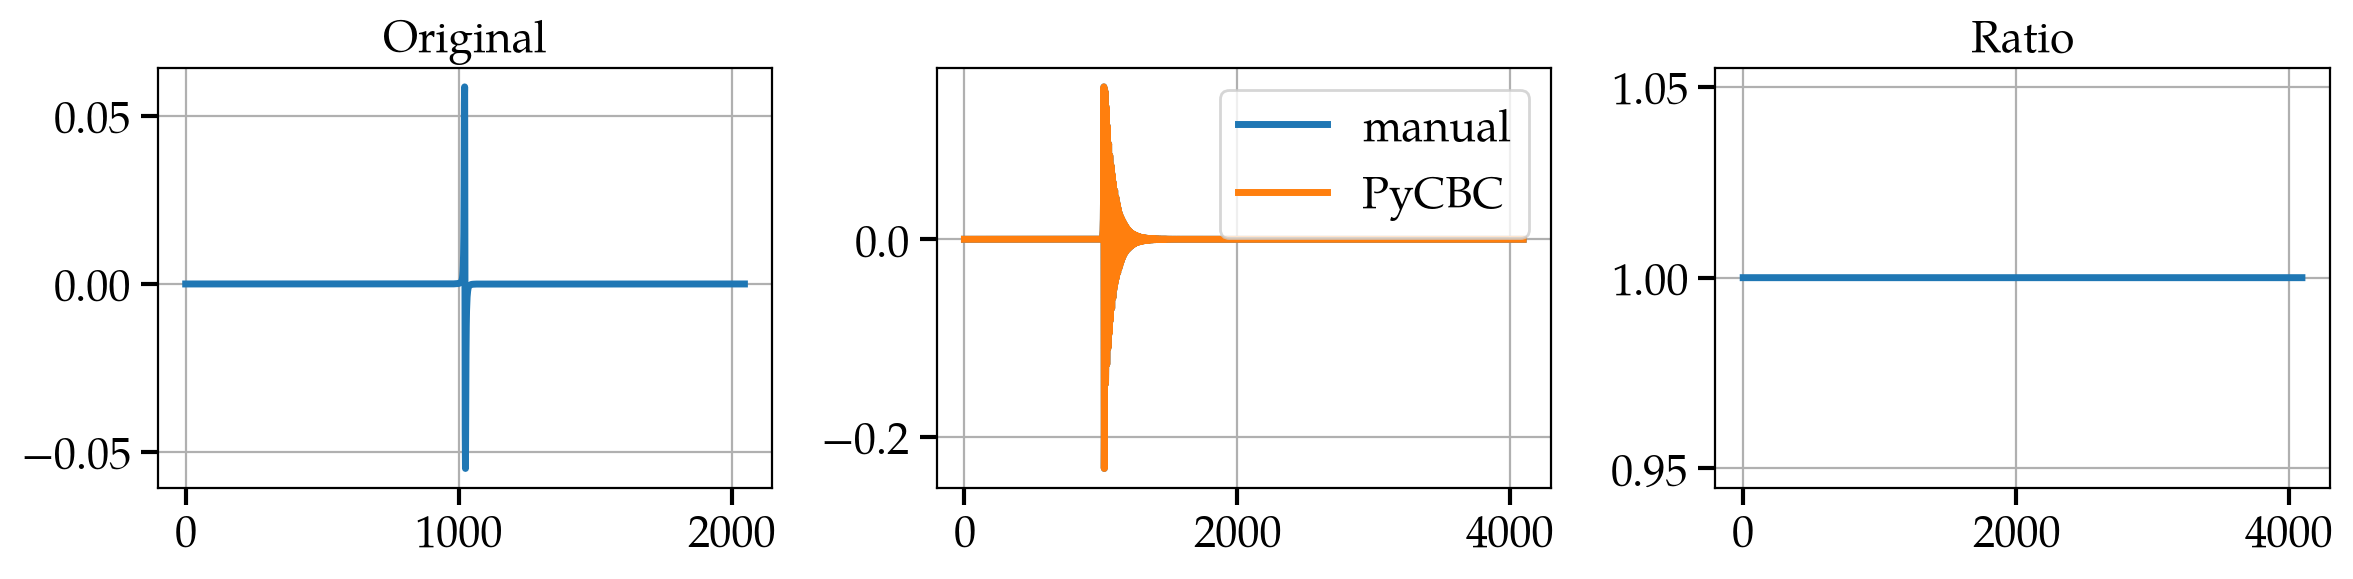

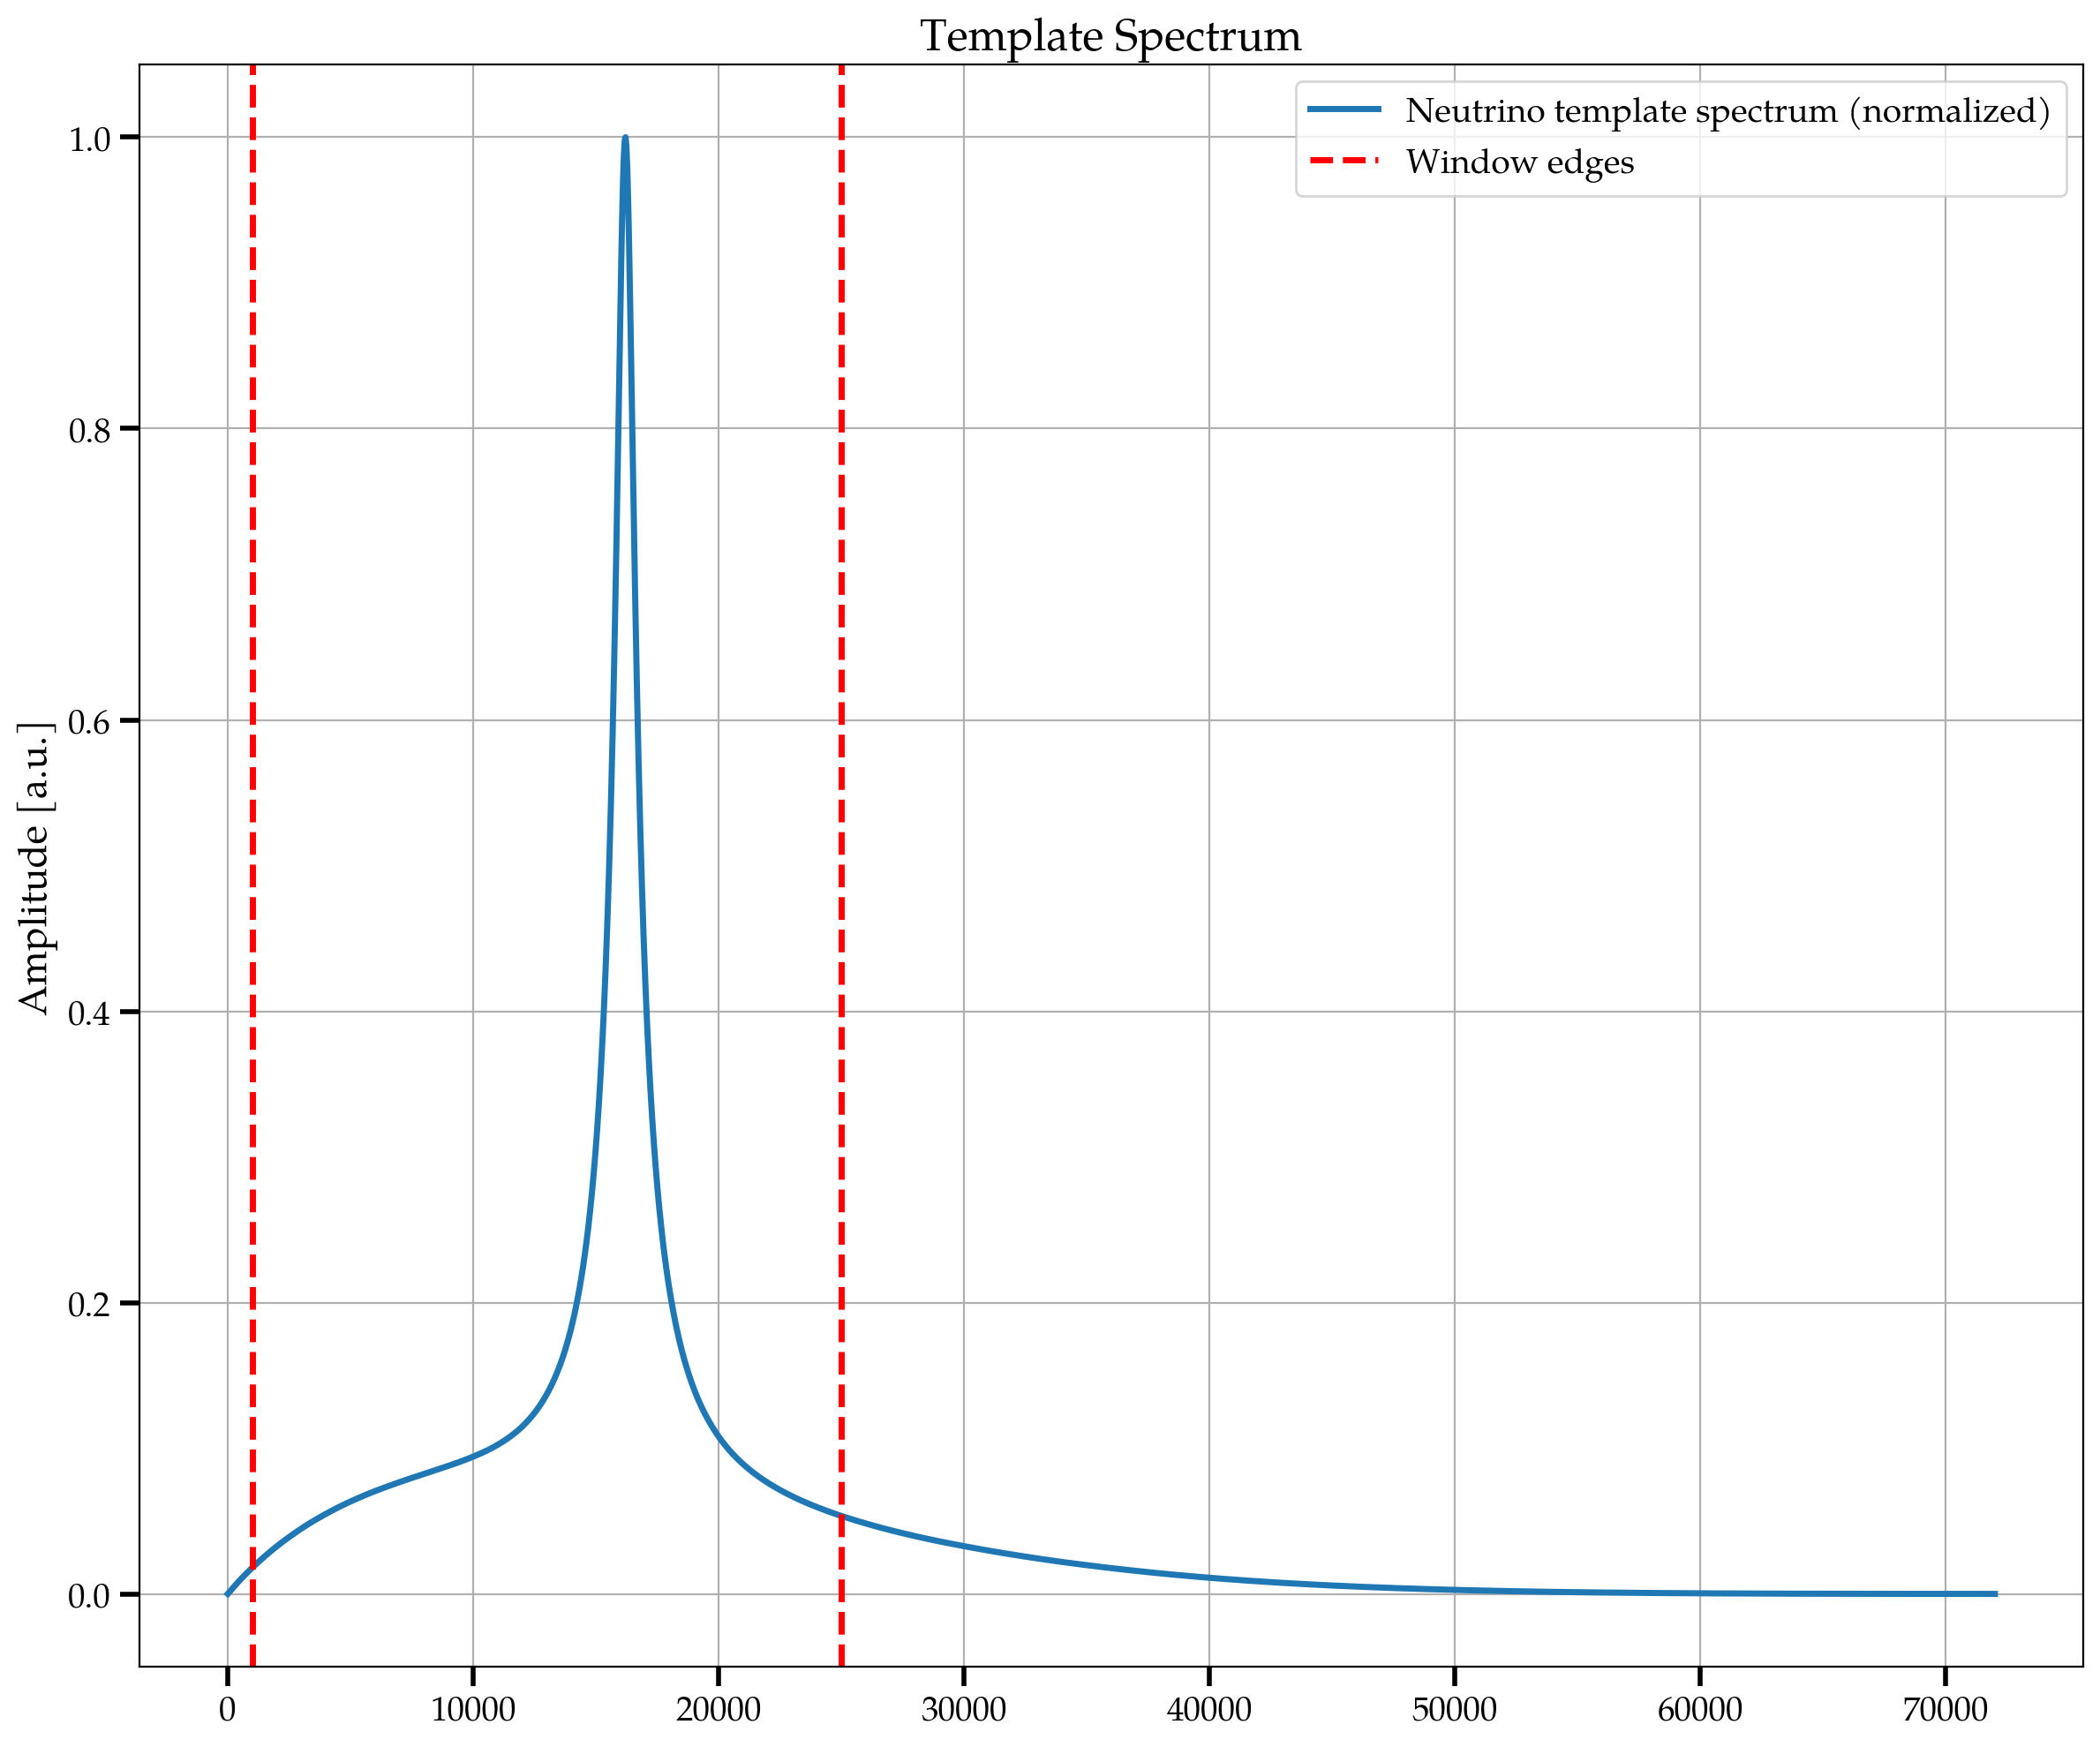

In [7]:
# ================= PyCBC traces GENERATING =================

template_PyCBC      = types.TimeSeries(padded_template, dt)
data_PyCBC          = types.TimeSeries(p_test, dt)
psd_PyCBC           = types.FrequencySeries(PSD, df)

# Templates
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].plot(p_template)
axs[0].set_title('Original')
axs[0].grid()

axs[1].plot(padded_template, label='manual')
axs[1].plot(template_PyCBC.data, label='PyCBC')
axs[1].legend()
axs[1].grid()

axs[2].set_title('Ratio')
axs[2].plot(padded_template / template_PyCBC.data)
axs[2].grid()

plt.tight_layout()

# Templates - frequency domain
plt.figure(figsize=(12, 10))

freqs_plot = np.fft.rfftfreq(len(padded_template), dt)
fft_vals_plot = np.fft.rfft(padded_template)
plt.plot(freqs_plot, np.abs(fft_vals_plot) / np.max(np.abs(fft_vals_plot)), label="Neutrino template spectrum (normalized)")
plt.ylabel('Amplitude [a.u.]', fontsize=16)
plt.title('Template Spectrum', fontsize=18)
plt.grid()
plt.tick_params(axis='both', which='major', labelsize=14, length=8, width=2)
plt.axvline(flow, color='r', linestyle='--', label='Window edges')
plt.axvline(fhigh, color='r', linestyle='--')
plt.legend(fontsize=14)

plt.tight_layout()

## Part 4: prep PyCBC files

In [9]:
print(f"Performing all matched filters in the region {flow} Hz to {fhigh} Hz")

snr_PyCBC = pycbc.filter.matched_filter(template              = template_PyCBC,
                                        data                  = data_PyCBC, 
                                        psd                   = psd_PyCBC, 
                                        low_frequency_cutoff  = flow, 
                                        high_frequency_cutoff = fhigh)


tmp, snr_JPP = matched_filter_JPP(p_test              = p_test, 
                                  padded_template     = padded_template, 
                                  psd                 = PSD, 
                                  sampling_rate       = sampling_rate, 
                                  flow                = flow, 
                                  fhigh               = fhigh)


Performing all matched filters in the region 1000 Hz to 25000 Hz


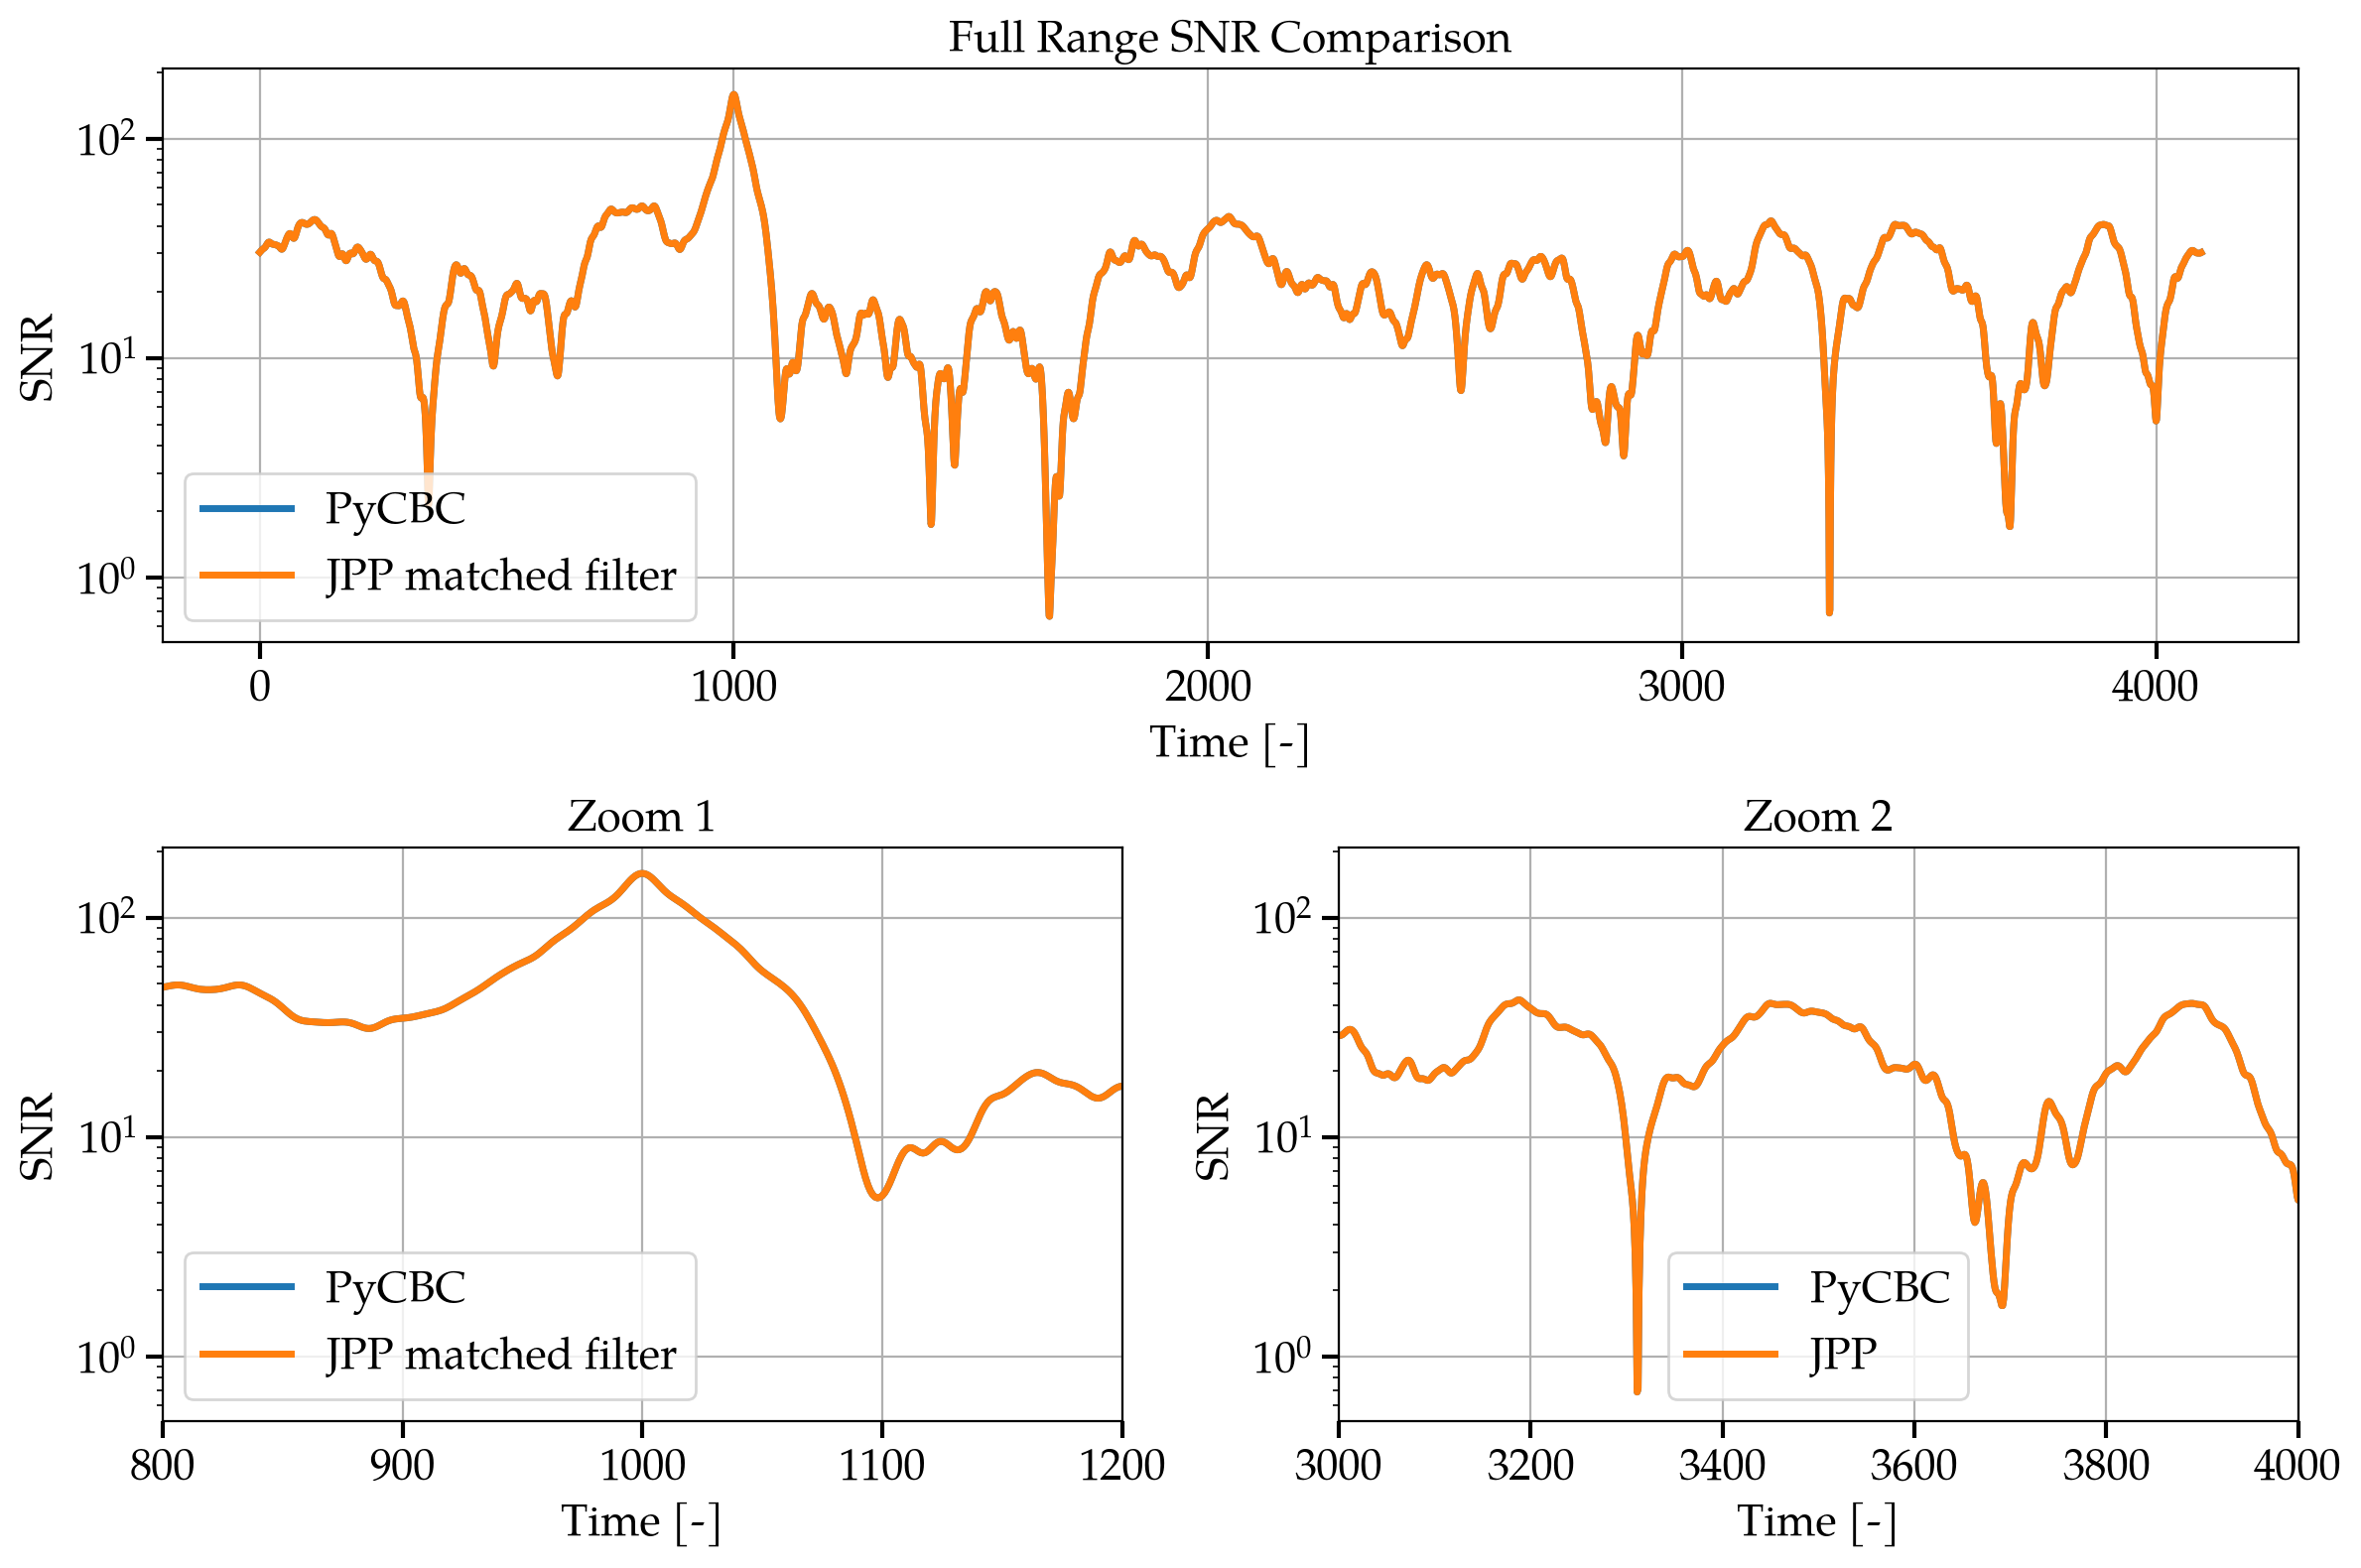

In [12]:
SNRvals     = np.abs(snr_PyCBC).data
SNRvals_JPP = np.abs(snr_JPP)


plt.figure(figsize=(12, 8))

# Top: full range comparison
plt.subplot(2, 1, 1)
plt.plot(SNRvals, label='PyCBC')
plt.plot(SNRvals_JPP, label='JPP matched filter')
plt.legend()
plt.yscale('log')
plt.grid()
plt.xlabel('Time [-]')
plt.ylabel('SNR')
plt.title('Full Range SNR Comparison')

# Bottom: two zoomed-in plots side by side
plt.subplot(2, 2, 3)
plt.plot(SNRvals, label='PyCBC')
plt.plot(SNRvals_JPP, label='JPP matched filter')
plt.xlim(800,1200)
plt.title('Zoom 1')
plt.legend()
plt.yscale('log')
plt.grid()
plt.xlabel('Time [-]')
plt.ylabel('SNR')

plt.subplot(2, 2, 4)
plt.plot(SNRvals, label='PyCBC')
plt.plot(SNRvals_JPP, label='JPP')
plt.xlim([3000, 4000])
plt.legend()
plt.yscale('log')
plt.grid()
plt.xlabel('Time [-]')
plt.ylabel('SNR')
plt.title('Zoom 2')

plt.tight_layout()
